In [ ]:
import pickle 
import matplotlib.pyplot as plt
import numpy as np

from utils.compute_per_attribute_privacy_budget import get_per_attribute_privacy_budget_descending

In [ ]:
LOCATIONS_DICT = {}

dataset = "adult"
name = "adult_unencoded"

In [ ]:
V = "0_2_final_plot_mse_nsb" # "0_2_final_plot_mse"
THR = 0.0
THR_mi = 0.05
PRIOR_PORTION = 100
NAME = f"{name}-{PRIOR_PORTION}"
NAME_ = f"{name}"
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_thr_{THR}_{THR_mi}_v_{V}"

LOCATIONS_DICT['cpm'] = FILE_LOCATION_SAVE

In [ ]:
GRF_THR = 0.3
V = f"0_2_grf_pcc_{GRF_THR}_plot_mse_nsb"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['grf_pcc_0.3'] = FILE_LOCATION_SAVE

In [ ]:
GRF_THR = 0.5
V = f"0_2_grf_pcc_{GRF_THR}_plot_mse_nsb"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['grf_pcc_0.5'] = FILE_LOCATION_SAVE

In [ ]:
V = "0_2_pckv_plot_mse"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['pckv'] = FILE_LOCATION_SAVE

In [ ]:
V = "0_2_its_plot_mse_nsb"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['its'] = FILE_LOCATION_SAVE

In [ ]:
V = "0_2_spl_plot_mse_nsb"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['spl'] = FILE_LOCATION_SAVE

In [ ]:
V = "0_2_jrr_plot_mse_nsb"
NAME = f"{name}"
PRIOR_PORTION = 100
FILE_LOCATION_SAVE = f"/home/sjay9734/CPM-publish/results/{dataset}/{NAME}_v_{V}"

LOCATIONS_DICT['jrr'] = FILE_LOCATION_SAVE

In [ ]:
for i in LOCATIONS_DICT.keys():
    print(i, LOCATIONS_DICT[i])

cpm /home/sjay9734/CPM-publish/results/adult/adult_unencoded-100_thr_0.0_0.05_v_0_2_final_plot_mse_nsb
grf_pcc_0.3 /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_grf_pcc_0.3_plot_mse_nsb
grf_pcc_0.5 /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_grf_pcc_0.5_plot_mse_nsb
pckv /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_pckv_plot_mse
its /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_its_plot_mse_nsb
spl /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_spl_plot_mse_nsb
jrr /home/sjay9734/CPM-publish/results/adult/adult_unencoded_v_0_2_jrr_plot_mse_nsb


In [ ]:
EPS_ARRAY = [1, 3, 5, 10, 20, 30 ,40]
MECHANISMS = ['cpm', 'its', 'jrr', 'grf_pcc_0.3', 'grf_pcc_0.5', 'spl'] #['cpm', 'its', 'pckv', 'jrr', 'grf_mi_0.1', 'grf_pcc_0.5', 'spl']
STYLES = ['--sb', '-^', '-*', '-o', '->', '-<', '-.', '--s']
LEGENDS = {'cpm': r"$\operatorname{CoP-LDP}$", 'pckv': r"$\operatorname{PCKV}$", 'its': r"$\operatorname{ITS}$", 'spl': r"$\operatorname{SPL}$", 'jrr': r"$\operatorname{JRR}$", 
           'grf_pcc_0.5': r"$\operatorname{GRF(THR_{PCC}=0.5)}$", 'grf_pcc_0.3': r"$\operatorname{GRF(THR_{PCC}=0.3)}$", 'grf_mi_0.1': r"$\operatorname{GRF(THR_{MI}=0.1)}$"}

In [ ]:
MECHANISMS

['cpm', 'its', 'jrr', 'grf_pcc_0.3', 'grf_pcc_0.5', 'spl']

In [ ]:
results_mechanism = {}

for mechanism in MECHANISMS:
    total_CIL = []
    total_DIL = []
    _0_1_loss = []

    for eps in EPS_ARRAY:
        with open(f"{LOCATIONS_DICT[mechanism]}_info_leakage_evaluation_eps_{eps}.pkl", 'rb') as file:
            load_data = pickle.load(file)
            print(load_data.keys())
            total_CIL.append(load_data["total_CIL"])
            total_DIL.append(load_data["total_DPL"])
            COLUMNS = load_data["COLUMNS"]
        # print(f"{LOCATIONS_DICT[mechanism]}_utility_evaluation_eps_{eps}.pkl")
        with open(f"{LOCATIONS_DICT[mechanism]}_utility_evaluation_eps_{eps}.pkl", 'rb') as file:
            load_data = pickle.load(file)
            _0_1_loss.append(load_data["_0_1_loss"])
            COLUMNS = load_data["COLUMNS"]

    results_mechanism[mechanism] = {"total_CIL": np.array(total_CIL),
                                    "total_DIL": np.array(total_DIL),
                                    "_0_1_loss": np.array(_0_1_loss)
                                    }

dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS', 'EPS_LIST'])
dict_keys(['total_CIL', 'total_DPL', 'inner_tot_normalised_DPL', 'inner_tot_normalised_CIL', 'tot_MI', 'COLUMNS

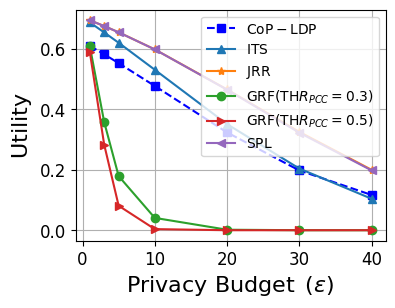

In [ ]:

legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    plt.plot(EPS_ARRAY, results_mechanism[mechanism]["_0_1_loss"], STYLES[i])
plt.legend(legend_list, fontsize=10)

plt.xlabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.ylabel(r"$\operatorname{Utility}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/results_utility.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)
# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/legend.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)


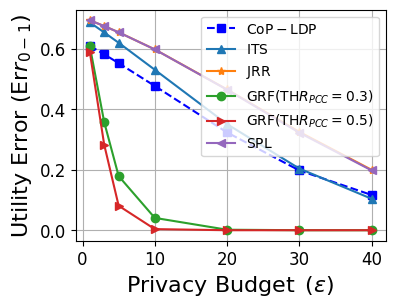

In [ ]:

legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    plt.plot(EPS_ARRAY, results_mechanism[mechanism]["_0_1_loss"], STYLES[i])
plt.legend(legend_list, fontsize=10)

plt.xlabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.ylabel(r"$\operatorname{Utility\ Error\ (Err_{0-1})}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/results_utility.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)
# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/legend.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)


[np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6)]
utility_dict  {'adult': array([0.60951894, 0.58168071, 0.55229754, 0.47695925, 0.32323959,
       0.19769183, 0.11657605])}
privacy_budget_dict  {'adult': [1, 3, 5, 10, 20, 30, 40]}
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  20 , y_r  30 , eps  0.2
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  20 , y_r  30 , eps  0.3
x_l  0.4769592515041563 , x_r  0.3232395893703601 , y_l  10 , y_r  20 , eps  0.4
x_l  0.552297544110533 , x_r  0.4769592515041563 , y_l  5 , y_r  10 , eps  0.5
x_l  0.6095189356649856 , x_r  0.5816807090525704 , y_l  1 , y_r  3 , eps  0.6
y_list  [np.float64(29.816151759521176), np.float64(21.85105563280362), np.float64(15.006467646095373), np.float64(8.470847446979871), np.float64(1.6838751474736833)]
utility_dict  {'adult': array([0.68718494, 0.65388905, 0.61970433, 0.53053124, 0.3507695 ,
       0.2038605 , 0.10407185])}
privacy_budget_dict  {'adult': [1, 3, 

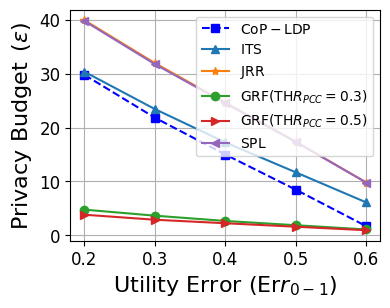

In [ ]:
UTILITY_ARRAY = list(np.arange(2, 7)/10)
print(UTILITY_ARRAY)

legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    y_list = []
    utility_dict = {dataset: results_mechanism[mechanism]["_0_1_loss"]}
    privacy_budget_dict = {dataset: EPS_ARRAY}
    print("utility_dict ", utility_dict)
    print("privacy_budget_dict ", privacy_budget_dict)
    for u in UTILITY_ARRAY:
        
        
        y_list.append(get_per_attribute_privacy_budget_descending(dataset=dataset, eps=u, eps_dict=privacy_budget_dict, privacy_leakage_dict=utility_dict))
    print("y_list ", y_list)
    plt.plot(UTILITY_ARRAY, y_list, STYLES[i])
plt.legend(legend_list, fontsize=10)

plt.ylabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.xlabel(r"$\operatorname{Utility\ Error\ (Err_{0-1})}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

eps_dict  {'adult': array([0, 0, 0, 0, 0, 0, 0])}
privacy_leakage_dict  {'adult': array([0.60951894, 0.58168071, 0.55229754, 0.47695925, 0.32323959,
       0.19769183, 0.11657605])}
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  0 , y_r  0 , eps  0.2
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  0 , y_r  0 , eps  0.3
x_l  0.4769592515041563 , x_r  0.3232395893703601 , y_l  0 , y_r  0 , eps  0.4
x_l  0.552297544110533 , x_r  0.4769592515041563 , y_l  0 , y_r  0 , eps  0.5
x_l  0.6095189356649856 , x_r  0.5816807090525704 , y_l  0 , y_r  0 , eps  0.6
y_list  [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
eps_dict  {'adult': array([0, 0, 0, 0, 0, 0, 0])}
privacy_leakage_dict  {'adult': array([0.68718494, 0.65388905, 0.61970433, 0.53053124, 0.3507695 ,
       0.2038605 , 0.10407185])}
x_l  0.20386049831812988 , x_r  0.10407184911091563 , y_l  0 , y_r  0 , eps  0.2
x_l  0.35076950231512244 , x_r  0.20386049831812988 , y_l  0 , y_

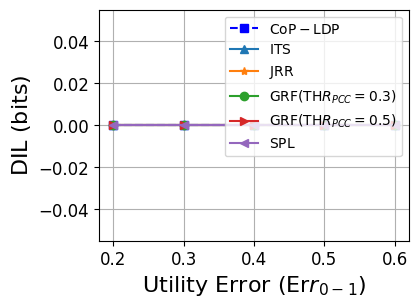

In [ ]:

legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    y_list = []
    privacy_leakage_dict = {dataset: results_mechanism[mechanism]["_0_1_loss"]}
    eps_dict = {dataset: np.sum(results_mechanism[mechanism]["total_DIL"], axis=1)}
    print("eps_dict ", eps_dict)
    print("privacy_leakage_dict ", privacy_leakage_dict)
    for u in UTILITY_ARRAY:
        
        
        y_list.append(get_per_attribute_privacy_budget_descending(dataset=dataset, eps=u, eps_dict=eps_dict, privacy_leakage_dict=privacy_leakage_dict))
    print("y_list ", y_list)
    plt.plot(UTILITY_ARRAY, y_list, STYLES[i])
plt.legend(legend_list, fontsize=10)

plt.ylabel(r"$\operatorname{DIL \ (bits)}$", fontsize=16)
plt.xlabel(r"$\operatorname{Utility\ Error\ (Err_{0-1})}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

eps_dict  {'adult': array([0.2043642 , 0.2323099 , 0.28366345, 0.48301466, 0.91815943,
       1.07867202, 1.02147426])}
privacy_leakage_dict  {'adult': array([0.60951894, 0.58168071, 0.55229754, 0.47695925, 0.32323959,
       0.19769183, 0.11657605])}
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  0.9181594345850712 , y_r  1.078672017794158 , eps  0.2
x_l  0.3232395893703601 , x_r  0.19769182646946173 , y_l  0.9181594345850712 , y_r  1.078672017794158 , eps  0.3
x_l  0.4769592515041563 , x_r  0.3232395893703601 , y_l  0.4830146623581215 , y_r  0.9181594345850712 , eps  0.4
x_l  0.552297544110533 , x_r  0.4769592515041563 , y_l  0.28366344602415416 , y_r  0.4830146623581215 , eps  0.5
x_l  0.6095189356649856 , x_r  0.5816807090525704 , y_l  0.2043642015379461 , y_r  0.23230989959128256 , eps  0.6
y_list  [np.float64(1.0757210221943878), np.float64(0.9478712067135752), np.float64(0.700868484710298), np.float64(0.4220469780771706), np.float64(0.21391988572668635)]
eps_dict  {'a

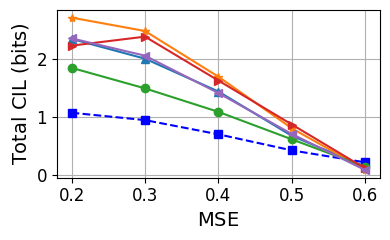

In [ ]:

legend_list = []

plt.figure(figsize=(4, 2.5))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    y_list = []
    privacy_leakage_dict = {dataset: results_mechanism[mechanism]["_0_1_loss"]}
    eps_dict = {dataset: np.sum(results_mechanism[mechanism]["total_CIL"], axis=1)}
    print("eps_dict ", eps_dict)
    print("privacy_leakage_dict ", privacy_leakage_dict)
    for u in UTILITY_ARRAY:
        
        
        y_list.append(get_per_attribute_privacy_budget_descending(dataset=dataset, eps=u, eps_dict=eps_dict, privacy_leakage_dict=privacy_leakage_dict))
    print("y_list ", y_list)
    plt.plot(np.array(UTILITY_ARRAY), y_list, STYLES[i])
# plt.legend(legend_list, fontsize=12)

plt.ylabel(r"$\operatorname{Total\ CIL \ (bits)}$", fontsize=14)
plt.xlabel(r"$\operatorname{MSE}$", fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 

plt.grid(True)


plt.tight_layout()
plt.savefig(f"/home/sjay9734/CPM-publish/plot_results/_final_{dataset}/results_CIL_utility_{dataset}_mse.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)

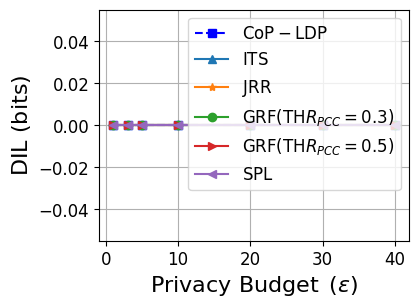

In [ ]:
legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    plt.plot(EPS_ARRAY, np.sum(results_mechanism[mechanism]["total_DIL"], axis=1), STYLES[i])
plt.legend(legend_list, fontsize=12)

plt.xlabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.ylabel(r"$\operatorname{DIL\ (bits)}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/results_DIL.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)


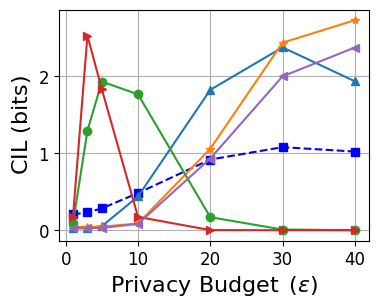

In [ ]:
legend_list = []

plt.figure(figsize=(4, 3))

for i, mechanism in enumerate(MECHANISMS):
    legend_list.append(LEGENDS[mechanism])
    plt.plot(EPS_ARRAY, np.sum(results_mechanism[mechanism]["total_CIL"], axis=1), STYLES[i])
# plt.legend(legend_list, fontsize=16)

plt.xlabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.ylabel(r"$\operatorname{CIL\ (bits)}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 
# plt.legend([ r"$i_{THR}=0.0$", r"$i_{THR}=1$", r"$i_{THR}=2$", r"$i_{THR}=5$"], fontsize=14, bbox_to_anchor=(1.08, 1.47), ncol=4)

plt.grid(True)

# plt.savefig("/home/sjay9734/CPM-publish/plot_results/_final_adult/results_CIL.png", format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)
